In [7]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

from scipy import stats
# from matplotlib.colors import LogNorm
import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize
from IPython.display import Image

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
target_dir_dr8 = '/Volumes/Samsung T5/tmp/dr8'
target_dir_dr9 = '/Volumes/Samsung T5/tmp/dr9m-sep26-2020'
data_dir = '/Volumes/Samsung T5/tmp/dr9_tests'

target_class = 'QSO'

target_path_list = glob.glob(os.path.join(target_dir_dr9, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
# target_path_list_dr8 = glob.glob(os.path.join(target_dir_dr8, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
target_path_list_dr8 = glob.glob(os.path.join(target_dir_dr8, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
print(len(target_path_list), len(target_path_list_dr8))

target_bits = {'LRG':0, 'ELG':1, 'QSO':2, 'BGS_ANY':60}
target_bit = target_bits[target_class]
target_columns = ['BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'RA', 'DEC', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'WISEMASK_W1', 'WISEMASK_W2', 'MASKBITS', 'PHOTSYS', 'DESI_TARGET']

37 41


-------
# North
---------

In [4]:
field = 'north'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [5]:
cat = []
for target_path in target_path_list:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    cat.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
cat = vstack(cat)
print(len(cat))

/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
0.10060010133637343 50828 505248
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
0.09238154294461236 106521 1153055
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-18.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/

In [6]:
dr8 = []
for target_path in target_path_list_dr8:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    dr8.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
dr8 = vstack(dr8)
print(len(dr8))

/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
0.08864572329643748 46322 522552
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
0.08326859007850615 98175 1179016
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-38.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-18.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-34.fits

In [7]:
print(len(cat))
print(len(dr8))
print(len(dr8)/len(cat))

1512059
1394818
0.9224626816810719


In [8]:
cat.write(os.path.join(data_dir, 'qso_dr9m_{}.fits'.format(field)))
dr8.write(os.path.join(data_dir, 'qso_dr8_{}.fits'.format(field)))

---------

In [22]:
field = 'north'
cat = Table.read(os.path.join(data_dir, 'qso_dr9m_{}.fits'.format(field)))
dr8 = Table.read(os.path.join(data_dir, 'qso_dr8_{}.fits'.format(field)))

In [24]:
norm = ImageNormalize(vmin=0., vmax=8)

fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr9.png'.format(target_class, field))
plt.close()

fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(dr8['RA'], dr8['DEC'], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr8.png'.format(target_class, field))
plt.close()

# Apply WISE mask
maskbits = [8, 9]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'][mask_clean], cat['DEC'][mask_clean], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr9_clean.png'.format(target_class, field))
plt.close()

0.04851265724419484


In [11]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], dr8['RA'], dr8['DEC'], search_radius=0.1, plot_q=False)
print(len(idx1)/len(cat))
print(len(idx2)/len(dr8))

cat_missing = cat[~np.in1d(np.arange(len(cat)), idx1)]
dr8_missing = dr8[~np.in1d(np.arange(len(dr8)), idx2)]
cat = cat[idx1]
dr8 = dr8[idx2]

print(len(cat_missing)+len(cat))
print(len(dr8_missing)+len(dr8))

Doubly matched objects = 1
Final matched objects = 1195448
0.7906093611426538
0.8570637889674495
1512059
1394818


In [12]:
cat_missing.write(os.path.join(data_dir, 'qso_no_match_dr9m_{}.fits'.format(field)))
dr8_missing.write(os.path.join(data_dir, 'qso_no_match_dr8_{}.fits'.format(field)))
cat.write(os.path.join(data_dir, 'qso_matched_dr9m_{}.fits'.format(field)))
dr8.write(os.path.join(data_dir, 'qso_matched_dr8_{}.fits'.format(field)))

------

In [41]:
field = 'north'
cat = Table.read(os.path.join(data_dir, 'qso_matched_dr9m_{}.fits'.format(field)))
dr8 = Table.read(os.path.join(data_dir, 'qso_matched_dr8_{}.fits'.format(field)))

In [42]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    dr8['gmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_G']/dr8['MW_TRANSMISSION_G'])
    dr8['rmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_R']/dr8['MW_TRANSMISSION_R'])
    dr8['zmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_Z']/dr8['MW_TRANSMISSION_Z'])
    dr8['w1mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W1']/dr8['MW_TRANSMISSION_W1'])
    dr8['w2mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W2']/dr8['MW_TRANSMISSION_W2'])

In [43]:
# Apply WISE mask
# Mask bits already applied in DR9: [1, 5, 6, 7, 10, 12, 13]
maskbits = [8, 9]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
dr8 = dr8[mask_clean]

0.036131224444726995


In [44]:
t = Table()
t['type'], t['counts'] = np.unique(dr8['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(dr8)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR8')
print(t)
print()

t = Table()
t['type'], t['counts'] = np.unique(cat['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR9')
print(t)

DR8
type  counts frac (%)
---- ------- --------
 PSF 1152255    100.0

DR9
type  counts frac (%)
---- ------- --------
 PSF 1152255    100.0


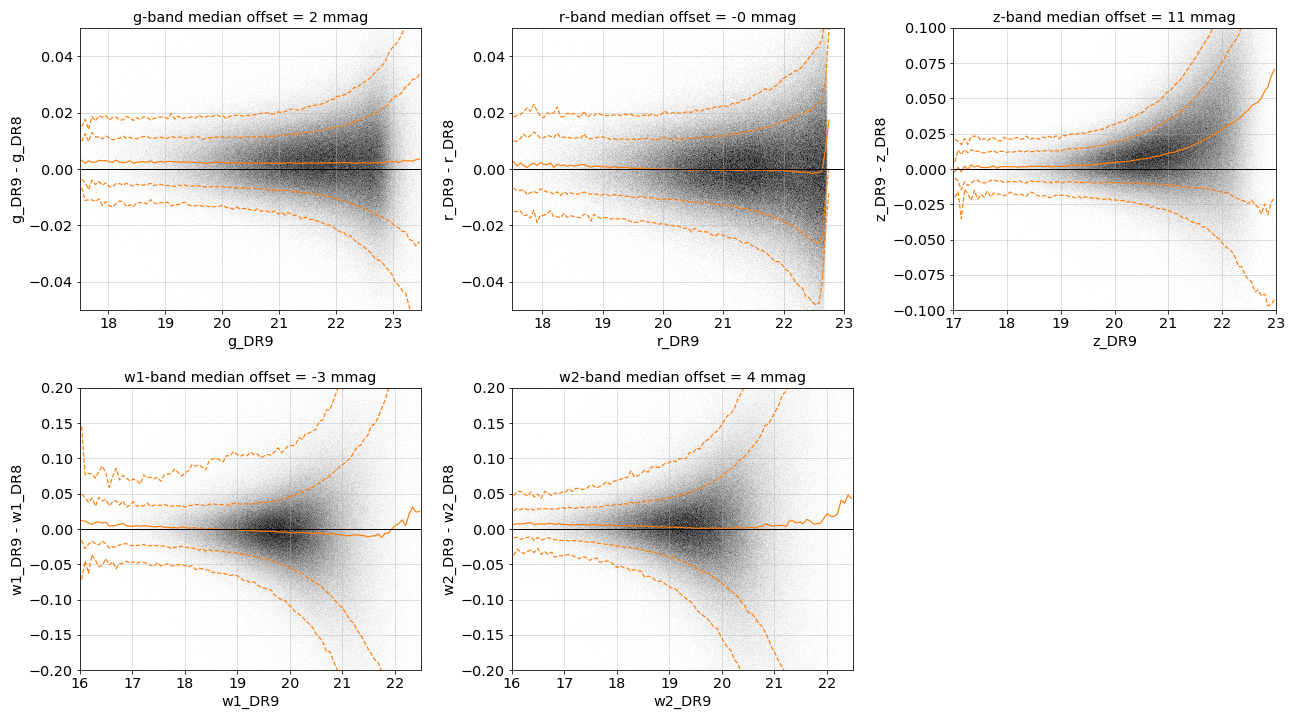

In [47]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[17.5, 23.5], [17.5, 23], [17, 23.], [16, 22.5], [16, 22.5]]
ylims = [[-0.05, 0.05], [-0.05, 0.05], [-0.1, 0.1], [-0.2, 0.2], [-0.2, 0.2]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

-------
# South
---------

In [24]:
field = 'south'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [25]:
cat = []
for target_path in target_path_list:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    cat.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
cat = vstack(cat)
print(len(cat))

/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
0.08237623762376238 832 10100
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
0.05841490780187974 8981 153745
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
0.06604456639412574 95413 1444676
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
0.0721149009891768 38712 536810
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
0.06959658881902193 40299 579037
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
0.09418344690104187 36946 392277
/Volumes/Samsung T5/tmp/dr9m-se

In [26]:
dr8 = []
for target_path in target_path_list_dr8:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    dr8.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
dr8 = vstack(dr8)
print(len(dr8))

/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
0.08505443076610031 836 9829
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
0.06792533034239864 212206 3124107
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
0.07201883492462821 219969 3054326
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
0.07243521834169461 24820 342651
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
0.07595599064901327 49354 649771
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
0.09611930872514128 29222 304018
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-38.fits
0.09295111004965619 37363 401964
/Volu

In [27]:
print(len(cat))
print(len(dr8))
print(len(dr8)/len(cat))

1925783
4204697
2.1833700889456393


In [28]:
cat.write(os.path.join(data_dir, 'qso_dr9m_{}.fits'.format(field)))
dr8.write(os.path.join(data_dir, 'qso_dr8_{}.fits'.format(field)))

---------

In [20]:
field = 'south'
cat = Table.read(os.path.join(data_dir, 'qso_dr9m_{}.fits'.format(field)))
dr8 = Table.read(os.path.join(data_dir, 'qso_dr8_{}.fits'.format(field)))

In [21]:
norm = ImageNormalize(vmin=0., vmax=10)

fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
plt.axis([360, 0, -70, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr9.png'.format(target_class, field))
plt.close()

fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(dr8['RA'], dr8['DEC'], color='C0', norm=norm)
plt.axis([360, 0, -70, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr8.png'.format(target_class, field))
plt.close()

# Apply WISE mask
maskbits = [8, 9]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'][mask_clean], cat['DEC'][mask_clean], color='C0', norm=norm)
plt.axis([360, 0, -70, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/{}_{}_dr9_clean.png'.format(target_class, field))
plt.close()

0.02602837391336407


In [32]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], dr8['RA'], dr8['DEC'], search_radius=0.1, plot_q=False)
print(len(idx1)/len(cat))
print(len(idx2)/len(dr8))

cat_missing = cat[~np.in1d(np.arange(len(cat)), idx1)]
dr8_missing = dr8[~np.in1d(np.arange(len(dr8)), idx2)]
cat = cat[idx1]
dr8 = dr8[idx2]

print(len(cat_missing)+len(cat))
print(len(dr8_missing)+len(dr8))

Doubly matched objects = 0
Final matched objects = 1653591
0.8586590493321418
0.3932723332977382
1925783
4204697


In [33]:
cat_missing.write(os.path.join(data_dir, 'qso_no_match_dr9m_{}.fits'.format(field)))
dr8_missing.write(os.path.join(data_dir, 'qso_no_match_dr8_{}.fits'.format(field)))
cat.write(os.path.join(data_dir, 'qso_matched_dr9m_{}.fits'.format(field)))
dr8.write(os.path.join(data_dir, 'qso_matched_dr8_{}.fits'.format(field)))

------

In [34]:
field = 'south'
cat = Table.read(os.path.join(data_dir, 'qso_matched_dr9m_{}.fits'.format(field)))
dr8 = Table.read(os.path.join(data_dir, 'qso_matched_dr8_{}.fits'.format(field)))

In [35]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    dr8['gmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_G']/dr8['MW_TRANSMISSION_G'])
    dr8['rmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_R']/dr8['MW_TRANSMISSION_R'])
    dr8['zmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_Z']/dr8['MW_TRANSMISSION_Z'])
    dr8['w1mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W1']/dr8['MW_TRANSMISSION_W1'])
    dr8['w2mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W2']/dr8['MW_TRANSMISSION_W2'])

In [36]:
# Apply WISE mask
# Mask bits already applied in DR9: [1, 5, 6, 7, 10, 12, 13]
maskbits = [8, 9]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
dr8 = dr8[mask_clean]

0.01974913990218863


In [37]:
t = Table()
t['type'], t['counts'] = np.unique(dr8['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(dr8)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR8')
print(t)
print()

t = Table()
t['type'], t['counts'] = np.unique(cat['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR9')
print(t)

DR8
type  counts frac (%)
---- ------- --------
 PSF 1620934    100.0

DR9
type  counts frac (%)
---- ------- --------
 PSF 1620934    100.0


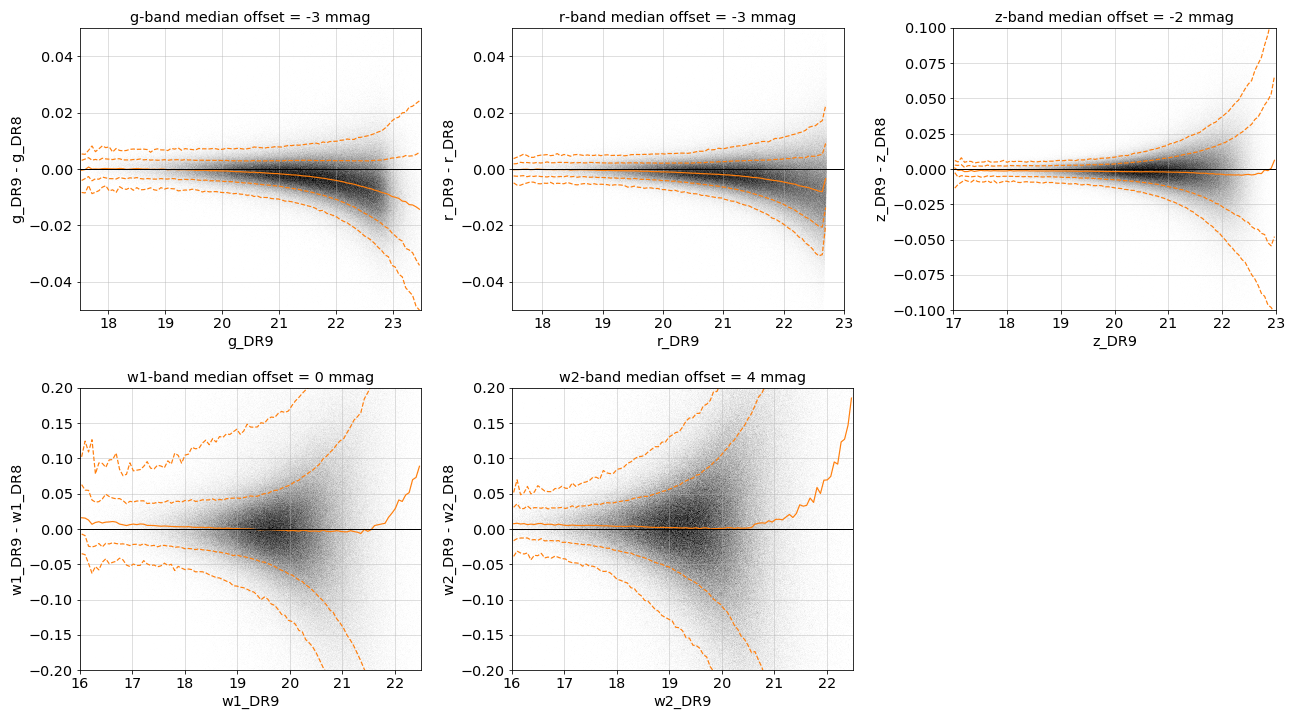

In [40]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[17.5, 23.5], [17.5, 23], [17, 23.], [16, 22.5], [16, 22.5]]
ylims = [[-0.05, 0.05], [-0.05, 0.05], [-0.1, 0.1], [-0.2, 0.2], [-0.2, 0.2]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')